In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# set which one-hot sample to compare (0-4)
# 0: corner (0,0)
# 1: corner (47,47)
# 2: center (24,24)
# 3: top edge (0,24)
# 4: left edge (24,0)
TEST_NUM = "populated0"

In [3]:
def load_rtl_layer(path, nfrac):
    raw = np.loadtxt(path, delimiter=',')   # shape (n_positions, n_channels)
    flat = raw.flatten()                     # row-major: channel varies fastest, matches (H,W,C) flatten
    return flat / (2 ** nfrac)

def load_ref_layer(path):
    return np.loadtxt(path, delimiter=',')   # already flat, already decimal

# every layer in pipeline order:
#   (short name, rtl filename suffix, hls4ml filename suffix, nfrac)
LAYER_SPECS = [
    ("conv0",  "conv0",  "q_activation",    6),
    ("pool0",  "pool0",  "max_pooling2d",   6),
    ("conv1",  "conv1",  "q_activation_1",  5),
    ("pool1",  "pool1",  "max_pooling2d_1", 5),
    ("conv2",  "conv2",  "q_activation_2",  5),
    ("pool2",  "pool2",  "max_pooling2d_2", 5),
    ("dense0", "dense0", "q_dense",         5),
    ("relu0",  "relu0",  "q_activation_3",  5),
    ("dense1", "dense1", "q_dense_1",       5),
    ("relu1",  "relu1",  "q_activation_4",  5),
    ("final",  "final",  "q_dense_2",       5),
]

def rtl_path(test_num, suffix):
    return f"populated_traces/rtl_{test_num}_{suffix}.csv"

def hls_path(test_num, suffix):
    return f"traces/hls4ml_{test_num}_{suffix}.csv"

def keras_path(test_num, suffix):
    return f"traces/keras_{test_num}_{suffix}.csv"

In [4]:
def diff_stats(rtl_p, ref_p, nfrac, label=None, outlier_threshold=0.1):
    rtl = load_rtl_layer(rtl_p, nfrac)
    ref = load_ref_layer(ref_p)
    n = min(len(rtl), len(ref))
    diff = np.abs(rtl[:n] - ref[:n])
    stats = {
        "label": label or ref_p, "mean": diff.mean(), "median": np.median(diff),
        "p95": np.percentile(diff, 95), "max": diff.max(),
        "outliers": int((diff > outlier_threshold).sum()), "n": diff.size,
    }
    print(f"{stats['label']:12s} mean={stats['mean']:.6f} median={stats['median']:.6f} "
          f"p95={stats['p95']:.6f} max={stats['max']:.6f} outliers={stats['outliers']}/{stats['n']} (>{outlier_threshold})")
    return stats

def run_full_comparison(test_num, ref_source="hls4ml"):
    print(f"=== TEST_NUM={test_num} ===")
    results = []
    for name, rtl_suffix, hls_suffix, nfrac in LAYER_SPECS:
        results.append(diff_stats(rtl_path(test_num, rtl_suffix), hls_path(test_num, hls_suffix), nfrac, label=name))
    return results

In [5]:
import contextlib
import io

buf = io.StringIO()

with contextlib.redirect_stdout(buf):
    results_by_test = {}
    # for test_num in range(5):
    #     results_by_test[test_num] = run_full_comparison(test_num)
    for label in ["populated0", "populated1", "populated2"]:
        print(f"\n{'='*70}\n{label}\n{'='*70}")
        results_by_test[label] = run_full_comparison(label)

# attach ULP figures using each layer's own nfrac (quantization step size)
nfrac_by_label = {name: nfrac for name, _, _, nfrac in LAYER_SPECS}
for results in results_by_test.values():
    for r in results:
        nfrac = nfrac_by_label[r["label"]]
        r["max_ulp"] = r["max"] * (2 ** nfrac)
        r["mean_ulp"] = r["mean"] * (2 ** nfrac)

positions = {
    0: "Corner (0,0)",
    1: "Corner (47,47)",
    2: "Center (24,24)",
    3: "Top edge (0,24)",
    4: "Left edge (24,0)",
}

OUTLIER_THRESHOLD = 0.1  # must match the threshold used in diff_stats/run_full_comparison
outlier_col = f"Outliers(>{OUTLIER_THRESHOLD})"

lines = []
lines.append("RTL vs. HLS4ML Comparison")
lines.append("-" * 70)
lines.append("")
lines.append("Final Output Layer: All Test Positions")
lines.append("-" * 70)
lines.append(f"{'Test Position':<20}{'Mean Err':>10}{'Mean(ULP)':>11}{'Max Err':>10}{'Max(ULP)':>10}{outlier_col:>16}")
for test_num, results in results_by_test.items():
    f = results[-1]
    pos_label = positions.get(test_num, f"Test {test_num}")
    lines.append(f"{pos_label:<20}{f['mean']:>10.6f}{f['mean_ulp']:>11.2f}{f['max']:>10.6f}{f['max_ulp']:>10.2f}{f['outliers']:>13d}/{f['n']}")

# per-layer breakdown for EVERY test position, not just one
for test_num, results in results_by_test.items():
    pos_label = positions.get(test_num, f"Test {test_num}")
    lines.append("")
    lines.append(f"Per-Layer Breakdown (Test {test_num}: {pos_label})")
    lines.append("-" * 70)
    lines.append(f"{'Layer':<12}{'Mean Err':>10}{'Mean(ULP)':>11}{'Max Err':>10}{'Max(ULP)':>10}{outlier_col:>16}")
    for r in results:
        lines.append(f"{r['label']:<12}{r['mean']:>10.6f}{r['mean_ulp']:>11.2f}{r['max']:>10.6f}{r['max_ulp']:>10.2f}{r['outliers']:>13d}/{r['n']}")

report_text = "\n".join(lines)
print(report_text)

with open("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/final_results_summary.txt", "w") as f:
    f.write(report_text)

RTL vs. HLS4ML Comparison
----------------------------------------------------------------------

Final Output Layer: All Test Positions
----------------------------------------------------------------------
Test Position         Mean Err  Mean(ULP)   Max Err  Max(ULP)  Outliers(>0.1)
Test populated0       0.181250       5.80  0.312500     10.00            3/5
Test populated1       0.137500       4.40  0.250000      8.00            2/5
Test populated2       0.175000       5.60  0.343750     11.00            2/5

Per-Layer Breakdown (Test populated0: Test populated0)
----------------------------------------------------------------------
Layer         Mean Err  Mean(ULP)   Max Err  Max(ULP)  Outliers(>0.1)
conv0         0.001296       0.08  0.078125      5.00            0/12684
pool0         0.002174       0.14  0.078125      5.00            0/726
conv1         0.061825       1.98  1.281250     41.00           94/648
pool1         0.127686       4.09  1.281250     41.00           35/128


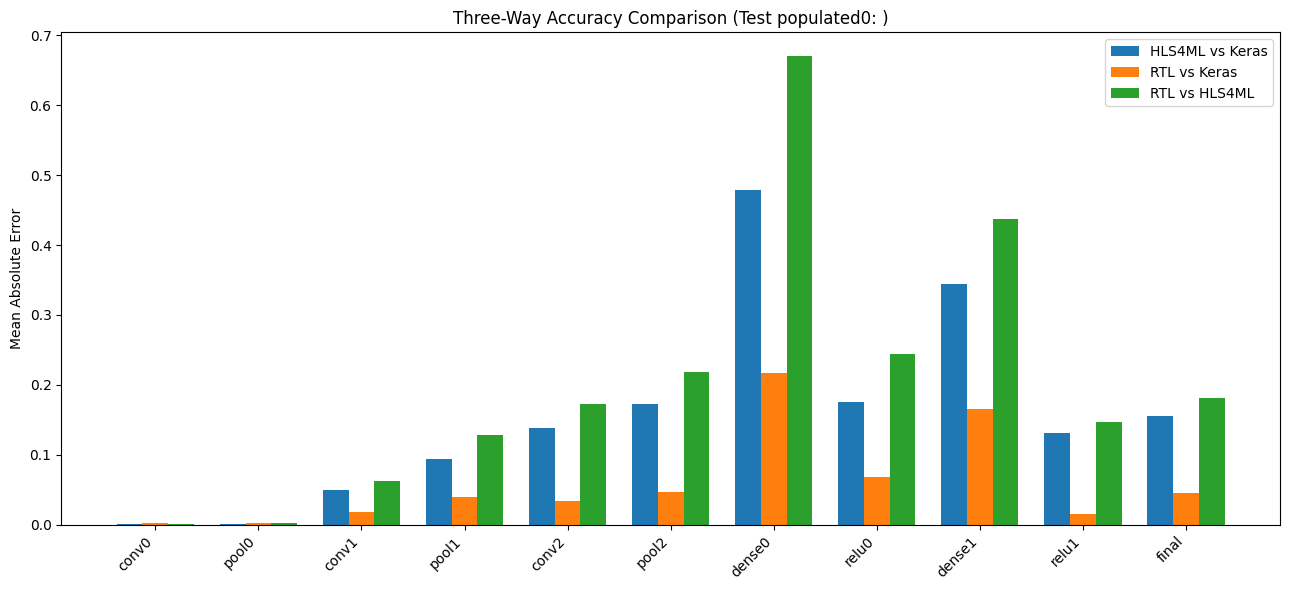

In [ ]:
def plot_three_way_comparison(test_num):
    # gather all three comparisons for this test
    hls_vs_keras = []
    rtl_vs_keras = []
    rtl_vs_hls = []

    for name, rtl_suffix, hls_suffix, nfrac in LAYER_SPECS:
        rtl = load_rtl_layer(rtl_path(test_num, rtl_suffix), nfrac)
        hls = load_ref_layer(hls_path(test_num, hls_suffix))
        keras = load_ref_layer(keras_path(test_num, hls_suffix))

        n = min(len(rtl), len(hls), len(keras))
        hls_vs_keras.append(np.abs(hls[:n] - keras[:n]).mean())
        rtl_vs_keras.append(np.abs(rtl[:n] - keras[:n]).mean())
        rtl_vs_hls.append(np.abs(rtl[:n] - hls[:n]).mean())

    names = [name for name, _, _, _ in LAYER_SPECS]
    x = np.arange(len(names))
    width = 0.25

    plt.figure(figsize=(13, 6))
    plt.bar(x - width, hls_vs_keras, width, label='HLS4ML vs Keras')
    plt.bar(x, rtl_vs_keras, width, label='RTL vs Keras')
    plt.bar(x + width, rtl_vs_hls, width, label='RTL vs HLS4ML')
    plt.xticks(x, names, rotation=45, ha='right')
    plt.ylabel('Mean Absolute Error')
    plt.title(f'Three-Way Accuracy Comparison (Test {test_num}: {positions.get(test_num, "")})')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_three_way_comparison("populated0")  

In [9]:
r = load_rtl_layer(rtl_path("populated0", "dense0"), 5)
h = load_ref_layer(hls_path("populated0", "q_dense"))
diff = np.abs(r - h)
worst = np.argmax(diff)
print(f"worst dense0 output index: {worst}, rtl={r[worst]}, hls4ml={h[worst]}, diff={diff[worst]}")

worst dense0 output index: 6, rtl=-2.0625, hls4ml=-0.28125, diff=1.78125


In [15]:
import tensorflow as tf
from qkeras import QConv2DBatchnorm, QActivation, QDense
from qkeras.utils import _add_supported_quantized_objects

def dice_loss(y_true, y_pred, delta=0.5):

    weights = tf.constant([3.0, 1.0, 2.0, 2.0, 0.1], dtype=tf.float32)
    y_pred = y_pred + 1e-8
    diff = y_true - y_pred
    abs_diff = tf.abs(diff)

    quadratic = tf.minimum(abs_diff, delta)
    linear = abs_diff - quadratic
    huber_loss = 0.5 * tf.square(quadratic) + delta * linear

    weighted_loss = weights * huber_loss
    return tf.reduce_mean(weighted_loss)

co = {}
_add_supported_quantized_objects(co)
co["dice_loss"] = dice_loss

model = tf.keras.models.load_model(
    "/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/Models/gaussian_nov24.keras",
    custom_objects=co
)
model.summary()

Model: "pp_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 q_conv2d_batchnorm (QConv2D  (None, 46, 46, 6)        85        
 Batchnorm)                                                      
                                                                 
 q_activation (QActivation)  (None, 46, 46, 6)         0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 11, 11, 6)        0         
 )                                                               
                                                                 
 q_conv2d_batchnorm_1 (QConv  (None, 9, 9, 8)          473       
 2DBatchnorm)                                                    
                                                                 
 q_activation_1 (QActivation  (None, 9, 9, 8)          0         
 )                                                        

In [16]:
layer_dense0 = model.get_layer("q_dense")
weights_dense0 = layer_dense0.get_weights()
print("number of weight arrays:", len(weights_dense0))
print("kernel shape:", weights_dense0[0].shape)
print("bias shape:", weights_dense0[1].shape)

number of weight arrays: 2
kernel shape: (10, 15)
bias shape: (15,)


In [17]:
flatten_raw = np.loadtxt(rtl_path("populated0", "pool2"), delimiter=',').flatten()
print("flatten_raw shape:", flatten_raw.shape)  # should be 10*1*1 = 10 (from pool2's OUTPUT_CHANNELS_CONV2=10, POOL2_OUT_WIDTH=1)

flatten_raw shape: (10,)


In [18]:
Nfrac_weight_dense0 = 5
Nfrac_input_dense0 = 5

out_idx = 6
weight_col = weights_dense0[0][:, out_idx]
bias_val = float(weights_dense0[1][out_idx])

total = 0
for in_idx in range(10):
    weight_int = round(float(weight_col[in_idx]) * (2**Nfrac_weight_dense0))
    pixel_int = int(flatten_raw[in_idx])
    total += (pixel_int * weight_int) >> Nfrac_input_dense0

bias_int = round(bias_val * (2**Nfrac_weight_dense0))
expected_raw = total + bias_int
print("expected raw output:", expected_raw)
print("expected decimal:", expected_raw / (2**Nfrac_weight_dense0))

rtl_raw = int(np.loadtxt(rtl_path("populated0", "dense0"), delimiter=',').flatten()[6])
print("actual RTL raw:", rtl_raw, "-> decimal:", rtl_raw / (2**Nfrac_weight_dense0))

expected raw output: -66
expected decimal: -2.0625
actual RTL raw: -66 -> decimal: -2.0625


In [19]:
import pandas as pd

keras_vs_hls = {}
keras_vs_rtl = {}
hls_vs_rtl = {}

rows = []
for test_label in ["populated0", "populated1", "populated2"]:
    for name, rtl_suffix, hls_suffix, nfrac in LAYER_SPECS:
        rtl = load_rtl_layer(rtl_path(test_label, rtl_suffix), nfrac)
        hls = load_ref_layer(hls_path(test_label, hls_suffix))
        keras = load_ref_layer(keras_path(test_label, hls_suffix))

        n = min(len(rtl), len(hls), len(keras))
        rtl_n, hls_n, keras_n = rtl[:n], hls[:n], keras[:n]

        d_hk = np.abs(hls_n - keras_n)
        d_kr = np.abs(keras_n - rtl_n)
        d_hr = np.abs(hls_n - rtl_n)

        rows.append({
            "test": test_label,
            "layer": name,
            "n": n,
            "keras_vs_hls_mean": d_hk.mean(),
            "keras_vs_hls_max": d_hk.max(),
            "keras_vs_rtl_mean": d_kr.mean(),
            "keras_vs_rtl_max": d_kr.max(),
            "hls_vs_rtl_mean": d_hr.mean(),
            "hls_vs_rtl_max": d_hr.max(),
        })

df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda x: f"{x:.5f}")
print(df.to_string(index=False))

df.to_csv("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/three_way_comparison.csv", index=False)

      test  layer     n  keras_vs_hls_mean  keras_vs_hls_max  keras_vs_rtl_mean  keras_vs_rtl_max  hls_vs_rtl_mean  hls_vs_rtl_max
populated0  conv0 12684            0.00043           0.03125            0.00173           0.09375          0.00130         0.07812
populated0  pool0   726            0.00060           0.03125            0.00278           0.09375          0.00217         0.07812
populated0  conv1   648            0.04905           0.79688            0.01828           0.48438          0.06182         1.28125
populated0  pool1   128            0.09436           0.79688            0.03967           0.48438          0.12769         1.28125
populated0  conv2    40            0.13828           1.00000            0.03438           0.48438          0.17266         1.46875
populated0  pool2    10            0.17188           1.00000            0.04688           0.46875          0.21875         1.46875
populated0 dense0    15            0.47917           1.21875            0.21667    